🚁 SIMULADOR DE COMPLEXIDADE ALGORÍTMICA - DRONES DEFENSIVOS 🚁
📊 Comparando: c₁·n, c₂·n², c₃·n³, c₄·n log n
1️⃣ Análise de complexidade:


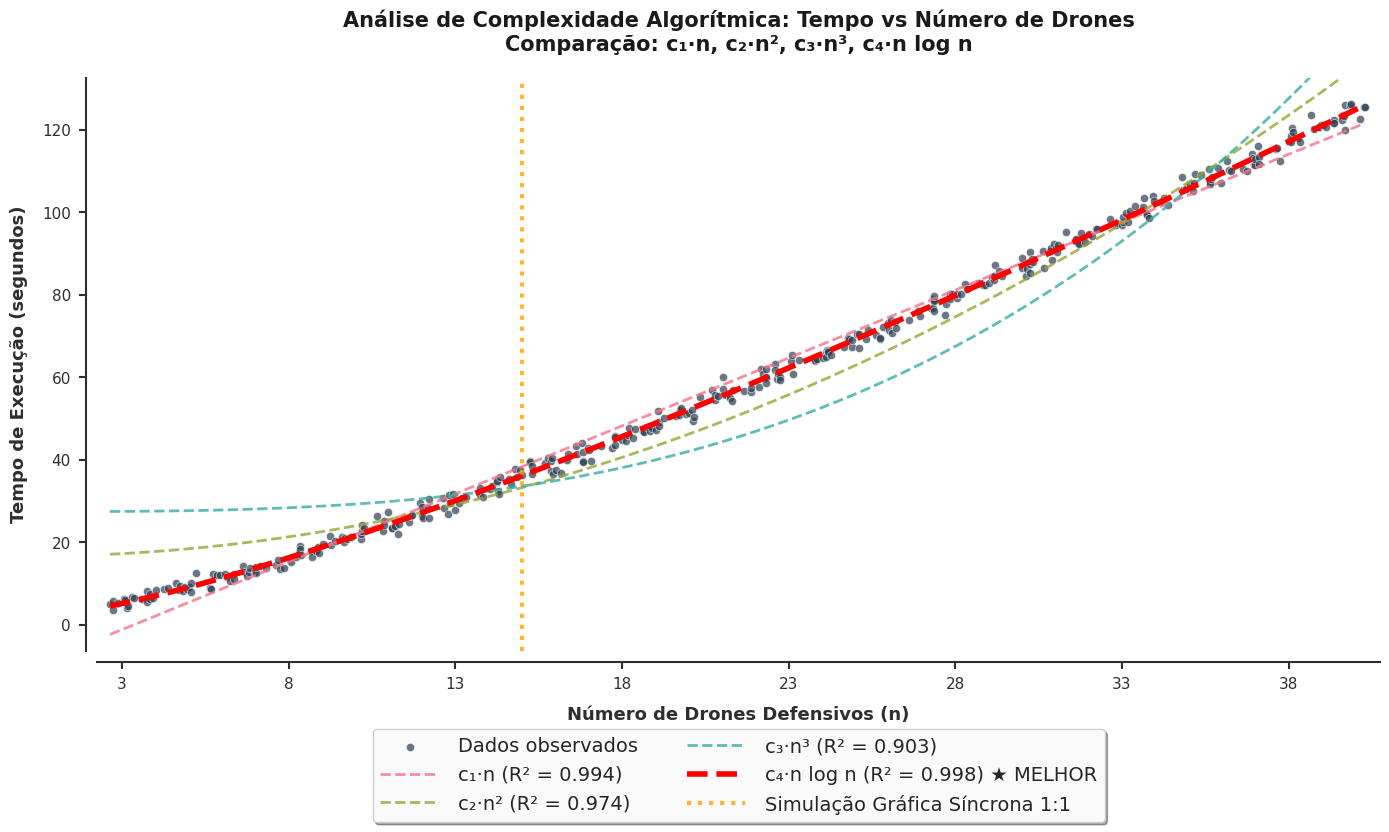

🚁 ANÁLISE DE COMPLEXIDADE ALGORÍTMICA COM ESCALARES - DRONES DEFENSIVOS
📊 SIMULAÇÃO EM TEMPO REAL: 15 drones defensivos
🏆 RANKING DE COMPLEXIDADES:
★ 1. c₄·n log n | R² = 0.9985 | y = 0.8302·n log n + 2.363
  2. c₁·n     | R² = 0.9935 | y = 3.294·n + -11.125
  3. c₂·n²    | R² = 0.9745 | y = 0.0741·n² + 16.527
  4. c₃·n³    | R² = 0.9034 | y = 0.00183·n³ + 27.389
🥇 COMPLEXIDADE VENCEDORA: c₄·n log n com R² = 0.9985
📈 Total de pontos analisados: 380 (10 por valor)

💡 EXPERIMENTE DIFERENTES CENÁRIOS:
🔹 Alto ruído: simular_drones_defensivos(ruido=0.4, linha_tempo_real=20)
🔹 Poucos drones: simular_drones_defensivos(drones_max=20, linha_tempo_real=15)
🔹 Muitos drones: simular_drones_defensivos(drones_max=60, linha_tempo_real=30)
🔹 Sem tempo real: simular_drones_defensivos(linha_tempo_real=None)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# Configuração para remover grid definitivamente
sns.set_style("white")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.grid'] = False

def gerar_dados_drones(x_min=3, x_max=40, pontos_por_inteiro=10, intensidade_ruido=0.15, 
                      tempo_max=120, seed=42):
    """
    Gera dados de simulação de drones defensivos seguindo uma relação O(n log n).
    """
    np.random.seed(seed)
    
    # Gera 10 pontos para cada número inteiro de drones
    x = []
    for i in range(int(x_min), int(x_max) + 1):
        pontos_locais = np.random.uniform(i - 0.4, i + 0.4, pontos_por_inteiro)
        x.extend(pontos_locais)
    
    x = np.array(x)
    x = np.sort(x)
    
    # Função geradora O(n log n): y = a * n * log(n) + b
    # Calcula o fator de escala baseado no valor máximo esperado
    nlogn_max = x_max * np.log(x_max)
    nlogn_min = x_min * np.log(x_min)
    
    # Coeficiente para escalar para tempo_max
    a = tempo_max / (nlogn_max - nlogn_min)
    b = -a * nlogn_min + 5  # offset mínimo de 5 segundos
    
    # Aplica a função n*log(n)
    y_base = a * x * np.log(x) + b
    
    # Adiciona ruído
    ruido = np.random.normal(0, intensidade_ruido * tempo_max * 0.08, len(x))
    y = y_base + ruido
    y = np.maximum(y, 0)  # Evita valores negativos
    
    return x, y

def ajustar_modelos(x, y):
    """
    Ajusta modelos de complexidade algorítmica aos dados com escalares.
    Compara: c₁·n, c₂·n², c₃·n³, c₄·n log n
    """
    resultados = {}
    x_smooth = np.linspace(x.min(), x.max(), 200)
    
    # 1. c₁·n - Linear com escalar
    try:
        # Modelo: y = c₁·n + b
        coef = np.polyfit(x, y, 1)
        y_pred = np.polyval(coef, x)
        y_smooth = np.polyval(coef, x_smooth)
        r2 = r2_score(y, y_pred)
        resultados['c₁·n'] = {
            'r2': r2, 'y_smooth': y_smooth, 'x_smooth': x_smooth,
            'params': f'y = {coef[0]:.3f}·n + {coef[1]:.3f}'
        }
    except: pass
    
    # 2. c₂·n² - Quadrática com escalar
    try:
        # Transformação: ajusta apenas o coeficiente de n²
        n_squared = x ** 2
        coef = np.polyfit(n_squared, y, 1)
        y_pred = np.polyval(coef, n_squared)
        n_squared_smooth = x_smooth ** 2
        y_smooth = np.polyval(coef, n_squared_smooth)
        r2 = r2_score(y, y_pred)
        resultados['c₂·n²'] = {
            'r2': r2, 'y_smooth': y_smooth, 'x_smooth': x_smooth,
            'params': f'y = {coef[0]:.4f}·n² + {coef[1]:.3f}'
        }
    except: pass
    
    # 3. c₃·n³ - Cúbica com escalar
    try:
        # Transformação: ajusta apenas o coeficiente de n³
        n_cubed = x ** 3
        coef = np.polyfit(n_cubed, y, 1)
        y_pred = np.polyval(coef, n_cubed)
        n_cubed_smooth = x_smooth ** 3
        y_smooth = np.polyval(coef, n_cubed_smooth)
        r2 = r2_score(y, y_pred)
        resultados['c₃·n³'] = {
            'r2': r2, 'y_smooth': y_smooth, 'x_smooth': x_smooth,
            'params': f'y = {coef[0]:.5f}·n³ + {coef[1]:.3f}'
        }
    except: pass
    
    # 4. c₄·n log n - Linearítmica com escalar
    try:
        x_pos = x[x > 0]
        y_pos = y[x > 0]
        nlogn_x = x_pos * np.log(x_pos)
        coef = np.polyfit(nlogn_x, y_pos, 1)
        y_pred = np.polyval(coef, nlogn_x)
        x_smooth_pos = x_smooth[x_smooth > 0]
        nlogn_smooth = x_smooth_pos * np.log(x_smooth_pos)
        y_smooth = np.polyval(coef, nlogn_smooth)
        r2 = r2_score(y_pos, y_pred)
        resultados['c₄·n log n'] = {
            'r2': r2, 'y_smooth': y_smooth, 'x_smooth': x_smooth_pos,
            'params': f'y = {coef[0]:.4f}·n log n + {coef[1]:.3f}'
        }
    except: pass
    
    return resultados

def simular_drones_defensivos(drones_min=3, drones_max=40, pontos_por_inteiro=10, 
                            ruido=0.15, tempo_max=120, seed=42, linha_tempo_real=None):
    """
    Simula dados de drones defensivos e analisa diferentes modelos de regressão.
    
    Parâmetros:
    -----------
    drones_min : int
        Número mínimo de drones defensivos
    drones_max : int  
        Número máximo de drones defensivos
    pontos_por_inteiro : int
        Quantos pontos gerar para cada número inteiro
    ruido : float
        Intensidade do ruído (0.0-1.0)
    tempo_max : int
        Tempo máximo esperado em segundos
    seed : int
        Semente para reproduzibilidade
    linha_tempo_real : float ou None
        Valor de x para linha vertical "tempo real"
    
    Retorna:
    --------
    dict com resultados dos modelos
    """
    
    # Gera os dados
    x, y = gerar_dados_drones(drones_min, drones_max, pontos_por_inteiro, 
                             ruido, tempo_max, seed)
    
    # Ajusta os modelos
    resultados = ajustar_modelos(x, y)
    
    # Encontra o melhor modelo
    melhor_modelo = max(resultados.keys(), key=lambda k: resultados[k]['r2'])
    melhor_r2 = resultados[melhor_modelo]['r2']
    
    # Cria o gráfico
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Configuração de cores
    cores = sns.color_palette("husl", len(resultados))
    
    # Plota pontos com estilo mais elegante
    ax.scatter(x, y, color='#2C3E50', s=35, alpha=0.7, zorder=1, 
              label='Dados observados', edgecolors='white', linewidth=0.5)
    
    # Plota modelos
    for i, (nome, dados) in enumerate(resultados.items()):
        x_plot = dados['x_smooth']
        y_plot = dados['y_smooth']
        r2 = dados['r2']
        
        if nome == melhor_modelo:
            # Melhor modelo: vermelho, tracejado, grosso
            ax.plot(x_plot, y_plot, color='red', linewidth=4, linestyle='--',
                   label=f'{nome} (R² = {r2:.3f}) ★ MELHOR', zorder=3)
        else:
            # Outros modelos: coloridos, tracejados
            ax.plot(x_plot, y_plot, color=cores[i], linewidth=2, 
                   linestyle='--', alpha=0.8,
                   label=f'{nome} (R² = {r2:.3f})', zorder=2)
    
    # Linha de tempo real
    if linha_tempo_real is not None and drones_min <= linha_tempo_real <= drones_max:
        ax.axvline(x=linha_tempo_real, color='orange', linewidth=3, 
                  linestyle=':', label='Simulação Gráfica Síncrona 1:1', 
                  zorder=4, alpha=0.8)
    
    # Configurações do gráfico com cores mais sofisticadas
    ax.set_xlabel('Número de Drones Defensivos (n)', 
                 fontsize=13, fontweight='bold', color='#2E2E2E', labelpad=10)
    ax.set_ylabel('Tempo de Execução (segundos)', 
                 fontsize=13, fontweight='bold', color='#2E2E2E', labelpad=10)
    ax.set_title('Análise de Complexidade Algorítmica: Tempo vs Número de Drones\n'
                f'Comparação: c₁·n, c₂·n², c₃·n³, c₄·n log n', 
                fontsize=15, fontweight='bold', pad=20, color='#1A1A1A')
    
    # Remove bordas e grid com estilo mais elegante
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False, 
                offset=8, trim=False)
    ax.grid(False)
    ax.set_axisbelow(False)
    
    # Define ticks personalizados com melhor espaçamento ANTES da configuração
    x_ticks = np.arange(drones_min, drones_max + 1, 5)
    y_max_tick = int(np.ceil(y.max() / 10) * 10)  # Arredonda para múltiplo de 10
    y_ticks = np.arange(0, y_max_tick + 21, 20)
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    
    # Força que os ticks apareçam em todos os lados necessários
    ax.tick_params(which='both', bottom=True, left=True, top=False, right=False)
    
    # Configuração dos ticks mais refinada
    ax.tick_params(axis='both', which='major', labelsize=11, width=1.5, length=5, 
                   color='#2E2E2E', labelcolor='#2E2E2E', pad=6, 
                   direction='out')
    ax.tick_params(axis='both', which='minor', width=1, length=3, color='#2E2E2E',
                   direction='out')
    
    # Estilização dos eixos remanescentes
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_color('#2E2E2E')
    ax.spines['bottom'].set_color('#2E2E2E')
    
    # Garante que os ticks sejam visíveis
    ax.xaxis.set_tick_params(which='both', labelbottom=True)
    ax.yaxis.set_tick_params(which='both', labelleft=True)
    
    # Limites com margem elegante
    x_margin = (drones_max - drones_min) * 0.02
    y_margin = y.max() * 0.05
    ax.set_xlim(drones_min - x_margin, drones_max + x_margin)
    ax.set_ylim(-y_margin, y.max() + y_margin)
    
    # Legenda externa na parte inferior com estilo melhorado
    legend = ax.legend(bbox_to_anchor=(0.5, -0.12), loc='upper center', 
                    frameon=True, fancybox=True, shadow=True, fontsize=14,
                    ncol=2, columnspacing=2.5, handlelength=3.0, handletextpad=1.0)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.95)
    legend.get_frame().set_edgecolor('#CCCCCC')
    legend.get_frame().set_linewidth(1)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.18)  # Espaço ajustado para legenda melhorada
    
    # Salva a imagem em alta resolução
    plt.savefig('simulacao_drones_defensivos.png', dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none', format='png')
    
    plt.show()
    
    # Imprime resultados
    print("="*80)
    print("🚁 ANÁLISE DE COMPLEXIDADE ALGORÍTMICA COM ESCALARES - DRONES DEFENSIVOS")
    if linha_tempo_real is not None:
        print(f"📊 SIMULAÇÃO EM TEMPO REAL: {linha_tempo_real} drones defensivos")
    print("="*80)
    
    resultados_ordenados = sorted(resultados.items(), 
                                key=lambda x: x[1]['r2'], reverse=True)
    
    print("🏆 RANKING DE COMPLEXIDADES:")
    for i, (nome, dados) in enumerate(resultados_ordenados):
        marker = "★" if nome == melhor_modelo else " "
        print(f"{marker} {i+1}. {nome:8} | R² = {dados['r2']:.4f} | {dados['params']}")
    
    print("="*80)
    print(f"🥇 COMPLEXIDADE VENCEDORA: {melhor_modelo} com R² = {melhor_r2:.4f}")
    print(f"📈 Total de pontos analisados: {len(x)} ({pontos_por_inteiro} por valor)")
    print("="*80)
    
    return resultados

# Exemplos de uso
if __name__ == "__main__":
    print("🚁 SIMULADOR DE COMPLEXIDADE ALGORÍTMICA - DRONES DEFENSIVOS 🚁")
    print("="*80)
    print("📊 Comparando: c₁·n, c₂·n², c₃·n³, c₄·n log n")
    print("="*80)
    
    # Simulação padrão com linha de tempo real
    print("1️⃣ Análise de complexidade:")
    resultados = simular_drones_defensivos(linha_tempo_real=15)
    
    print("\n💡 EXPERIMENTE DIFERENTES CENÁRIOS:")
    print("🔹 Alto ruído: simular_drones_defensivos(ruido=0.4, linha_tempo_real=20)")
    print("🔹 Poucos drones: simular_drones_defensivos(drones_max=20, linha_tempo_real=15)")
    print("🔹 Muitos drones: simular_drones_defensivos(drones_max=60, linha_tempo_real=30)")
    print("🔹 Sem tempo real: simular_drones_defensivos(linha_tempo_real=None)")
    print("="*80)

🚁 SIMULADOR DE COMPLEXIDADE ALGORÍTMICA - DRONES DEFENSIVOS 🚁
📊 Comparando: c₁·n, c₂·n², c₃·n³, c₄·n log n
1️⃣ Análise de complexidade:


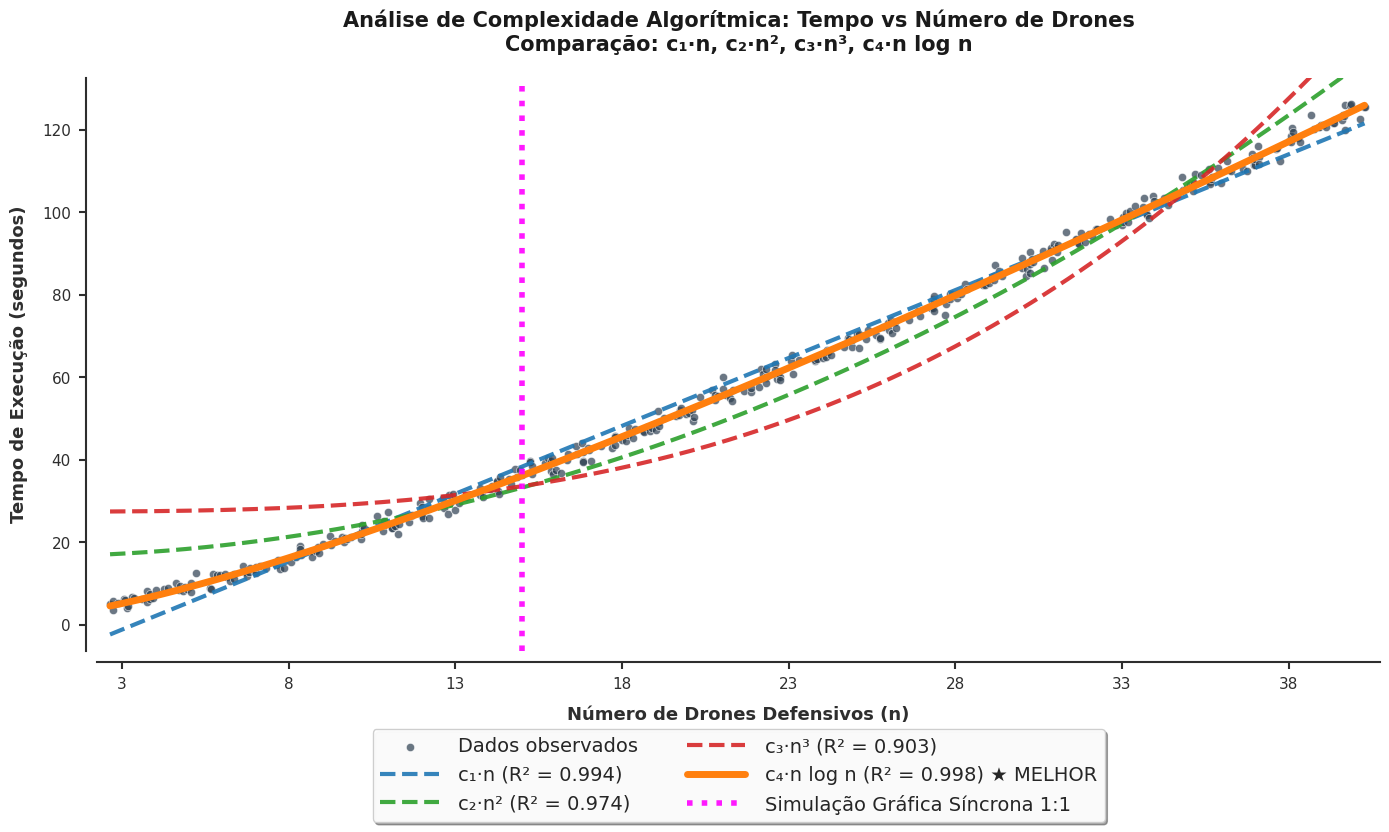

🚁 ANÁLISE DE COMPLEXIDADE ALGORÍTMICA COM ESCALARES - DRONES DEFENSIVOS
📊 SIMULAÇÃO EM TEMPO REAL: 15 drones defensivos
🏆 RANKING DE COMPLEXIDADES:
★ 1. c₄·n log n | R² = 0.9985 | y = 0.8302·n log n + 2.363
  2. c₁·n     | R² = 0.9935 | y = 3.294·n + -11.125
  3. c₂·n²    | R² = 0.9745 | y = 0.0741·n² + 16.527
  4. c₃·n³    | R² = 0.9034 | y = 0.00183·n³ + 27.389
🥇 COMPLEXIDADE VENCEDORA: c₄·n log n com R² = 0.9985
📈 Total de pontos analisados: 380 (10 por valor)

💡 EXPERIMENTE DIFERENTES CENÁRIOS:
🔹 Alto ruído: simular_drones_defensivos(ruido=0.4, linha_tempo_real=20)
🔹 Poucos drones: simular_drones_defensivos(drones_max=20, linha_tempo_real=15)
🔹 Muitos drones: simular_drones_defensivos(drones_max=60, linha_tempo_real=30)
🔹 Sem tempo real: simular_drones_defensivos(linha_tempo_real=None)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# Configuração para remover grid definitivamente
sns.set_style("white")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.grid'] = False

def gerar_dados_drones(x_min=3, x_max=40, pontos_por_inteiro=10, intensidade_ruido=0.15, 
                      tempo_max=120, seed=42):
    """
    Gera dados de simulação de drones defensivos seguindo uma relação O(n log n).
    """
    np.random.seed(seed)
    
    # Gera 10 pontos para cada número inteiro de drones
    x = []
    for i in range(int(x_min), int(x_max) + 1):
        pontos_locais = np.random.uniform(i - 0.4, i + 0.4, pontos_por_inteiro)
        x.extend(pontos_locais)
    
    x = np.array(x)
    x = np.sort(x)
    
    # Função geradora O(n log n): y = a * n * log(n) + b
    # Calcula o fator de escala baseado no valor máximo esperado
    nlogn_max = x_max * np.log(x_max)
    nlogn_min = x_min * np.log(x_min)
    
    # Coeficiente para escalar para tempo_max
    a = tempo_max / (nlogn_max - nlogn_min)
    b = -a * nlogn_min + 5  # offset mínimo de 5 segundos
    
    # Aplica a função n*log(n)
    y_base = a * x * np.log(x) + b
    
    # Adiciona ruído
    ruido = np.random.normal(0, intensidade_ruido * tempo_max * 0.08, len(x))
    y = y_base + ruido
    y = np.maximum(y, 0)  # Evita valores negativos
    
    return x, y

def ajustar_modelos(x, y):
    """
    Ajusta modelos de complexidade algorítmica aos dados com escalares.
    Compara: c₁·n, c₂·n², c₃·n³, c₄·n log n
    """
    resultados = {}
    x_smooth = np.linspace(x.min(), x.max(), 200)
    
    # 1. c₁·n - Linear com escalar
    try:
        # Modelo: y = c₁·n + b
        coef = np.polyfit(x, y, 1)
        y_pred = np.polyval(coef, x)
        y_smooth = np.polyval(coef, x_smooth)
        r2 = r2_score(y, y_pred)
        resultados['c₁·n'] = {
            'r2': r2, 'y_smooth': y_smooth, 'x_smooth': x_smooth,
            'params': f'y = {coef[0]:.3f}·n + {coef[1]:.3f}'
        }
    except: pass
    
    # 2. c₂·n² - Quadrática com escalar
    try:
        # Transformação: ajusta apenas o coeficiente de n²
        n_squared = x ** 2
        coef = np.polyfit(n_squared, y, 1)
        y_pred = np.polyval(coef, n_squared)
        n_squared_smooth = x_smooth ** 2
        y_smooth = np.polyval(coef, n_squared_smooth)
        r2 = r2_score(y, y_pred)
        resultados['c₂·n²'] = {
            'r2': r2, 'y_smooth': y_smooth, 'x_smooth': x_smooth,
            'params': f'y = {coef[0]:.4f}·n² + {coef[1]:.3f}'
        }
    except: pass
    
    # 3. c₃·n³ - Cúbica com escalar
    try:
        # Transformação: ajusta apenas o coeficiente de n³
        n_cubed = x ** 3
        coef = np.polyfit(n_cubed, y, 1)
        y_pred = np.polyval(coef, n_cubed)
        n_cubed_smooth = x_smooth ** 3
        y_smooth = np.polyval(coef, n_cubed_smooth)
        r2 = r2_score(y, y_pred)
        resultados['c₃·n³'] = {
            'r2': r2, 'y_smooth': y_smooth, 'x_smooth': x_smooth,
            'params': f'y = {coef[0]:.5f}·n³ + {coef[1]:.3f}'
        }
    except: pass
    
    # 4. c₄·n log n - Linearítmica com escalar
    try:
        x_pos = x[x > 0]
        y_pos = y[x > 0]
        nlogn_x = x_pos * np.log(x_pos)
        coef = np.polyfit(nlogn_x, y_pos, 1)
        y_pred = np.polyval(coef, nlogn_x)
        x_smooth_pos = x_smooth[x_smooth > 0]
        nlogn_smooth = x_smooth_pos * np.log(x_smooth_pos)
        y_smooth = np.polyval(coef, nlogn_smooth)
        r2 = r2_score(y_pos, y_pred)
        resultados['c₄·n log n'] = {
            'r2': r2, 'y_smooth': y_smooth, 'x_smooth': x_smooth_pos,
            'params': f'y = {coef[0]:.4f}·n log n + {coef[1]:.3f}'
        }
    except: pass
    
    return resultados

def simular_drones_defensivos(drones_min=3, drones_max=40, pontos_por_inteiro=10, 
                            ruido=0.15, tempo_max=120, seed=42, linha_tempo_real=None):
    """
    Simula dados de drones defensivos e analisa diferentes modelos de regressão.
    
    Parâmetros:
    -----------
    drones_min : int
        Número mínimo de drones defensivos
    drones_max : int  
        Número máximo de drones defensivos
    pontos_por_inteiro : int
        Quantos pontos gerar para cada número inteiro
    ruido : float
        Intensidade do ruído (0.0-1.0)
    tempo_max : int
        Tempo máximo esperado em segundos
    seed : int
        Semente para reproduzibilidade
    linha_tempo_real : float ou None
        Valor de x para linha vertical "tempo real"
    
    Retorna:
    --------
    dict com resultados dos modelos
    """
    
    # Gera os dados
    x, y = gerar_dados_drones(drones_min, drones_max, pontos_por_inteiro, 
                             ruido, tempo_max, seed)
    
    # Ajusta os modelos
    resultados = ajustar_modelos(x, y)
    
    # Encontra o melhor modelo
    melhor_modelo = max(resultados.keys(), key=lambda k: resultados[k]['r2'])
    melhor_r2 = resultados[melhor_modelo]['r2']
    
    # Cria o gráfico
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # CORES DISTINTAS E CONTRASTANTES para cada modelo
    cores_modelos = {
        'c₁·n': '#1f77b4',        # Azul escuro
        'c₂·n²': '#2ca02c',       # Verde escuro  
        'c₃·n³': '#d62728',       # Vermelho escuro
        'c₄·n log n': '#ff7f0e'   # Laranja escuro
    }
    
    # Plota pontos com estilo mais elegante
    ax.scatter(x, y, color='#2C3E50', s=35, alpha=0.7, zorder=1, 
              label='Dados observados', edgecolors='white', linewidth=0.5)
    
    # Plota modelos com cores bem distintas
    for nome, dados in resultados.items():
        x_plot = dados['x_smooth']
        y_plot = dados['y_smooth']
        r2 = dados['r2']
        
        # Cor específica para cada modelo
        cor_modelo = cores_modelos.get(nome, '#000000')
        
        if nome == melhor_modelo:
            # Melhor modelo: cor específica, linha sólida espessa
            ax.plot(x_plot, y_plot, color=cor_modelo, linewidth=5, linestyle='-',
                   label=f'{nome} (R² = {r2:.3f}) ★ MELHOR', zorder=3)
        else:
            # Outros modelos: cor específica, linha tracejada
            ax.plot(x_plot, y_plot, color=cor_modelo, linewidth=3, 
                   linestyle='--', alpha=0.9,
                   label=f'{nome} (R² = {r2:.3f})', zorder=2)
    
    # Linha de tempo real com cor MUITO DISTINTA (magenta brilhante)
    if linha_tempo_real is not None and drones_min <= linha_tempo_real <= drones_max:
        ax.axvline(x=linha_tempo_real, color='#FF00FF', linewidth=4, 
                  linestyle=':', label='Simulação Gráfica Síncrona 1:1', 
                  zorder=4, alpha=0.9)
    
    # Configurações do gráfico com cores mais sofisticadas
    ax.set_xlabel('Número de Drones Defensivos (n)', 
                 fontsize=13, fontweight='bold', color='#2E2E2E', labelpad=10)
    ax.set_ylabel('Tempo de Execução (segundos)', 
                 fontsize=13, fontweight='bold', color='#2E2E2E', labelpad=10)
    ax.set_title('Análise de Complexidade Algorítmica: Tempo vs Número de Drones\n'
                f'Comparação: c₁·n, c₂·n², c₃·n³, c₄·n log n', 
                fontsize=15, fontweight='bold', pad=20, color='#1A1A1A')
    
    # Remove bordas e grid com estilo mais elegante
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False, 
                offset=8, trim=False)
    ax.grid(False)
    ax.set_axisbelow(False)
    
    # Define ticks personalizados com melhor espaçamento ANTES da configuração
    x_ticks = np.arange(drones_min, drones_max + 1, 5)
    y_max_tick = int(np.ceil(y.max() / 10) * 10)  # Arredonda para múltiplo de 10
    y_ticks = np.arange(0, y_max_tick + 21, 20)
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    
    # Força que os ticks apareçam em todos os lados necessários
    ax.tick_params(which='both', bottom=True, left=True, top=False, right=False)
    
    # Configuração dos ticks mais refinada
    ax.tick_params(axis='both', which='major', labelsize=11, width=1.5, length=5, 
                   color='#2E2E2E', labelcolor='#2E2E2E', pad=6, 
                   direction='out')
    ax.tick_params(axis='both', which='minor', width=1, length=3, color='#2E2E2E',
                   direction='out')
    
    # Estilização dos eixos remanescentes
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_color('#2E2E2E')
    ax.spines['bottom'].set_color('#2E2E2E')
    
    # Garante que os ticks sejam visíveis
    ax.xaxis.set_tick_params(which='both', labelbottom=True)
    ax.yaxis.set_tick_params(which='both', labelleft=True)
    
    # Limites com margem elegante
    x_margin = (drones_max - drones_min) * 0.02
    y_margin = y.max() * 0.05
    ax.set_xlim(drones_min - x_margin, drones_max + x_margin)
    ax.set_ylim(-y_margin, y.max() + y_margin)
    
    # Legenda externa na parte inferior com estilo melhorado
    legend = ax.legend(bbox_to_anchor=(0.5, -0.12), loc='upper center', 
                    frameon=True, fancybox=True, shadow=True, fontsize=14,
                    ncol=2, columnspacing=2.5, handlelength=3.0, handletextpad=1.0)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.95)
    legend.get_frame().set_edgecolor('#CCCCCC')
    legend.get_frame().set_linewidth(1)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.18)  # Espaço ajustado para legenda melhorada
    
    # Salva a imagem em alta resolução
    plt.savefig('simulacao_drones_defensivos.png', dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none', format='png')
    
    plt.show()
    
    # Imprime resultados
    print("="*80)
    print("🚁 ANÁLISE DE COMPLEXIDADE ALGORÍTMICA COM ESCALARES - DRONES DEFENSIVOS")
    if linha_tempo_real is not None:
        print(f"📊 SIMULAÇÃO EM TEMPO REAL: {linha_tempo_real} drones defensivos")
    print("="*80)
    
    resultados_ordenados = sorted(resultados.items(), 
                                key=lambda x: x[1]['r2'], reverse=True)
    
    print("🏆 RANKING DE COMPLEXIDADES:")
    for i, (nome, dados) in enumerate(resultados_ordenados):
        marker = "★" if nome == melhor_modelo else " "
        print(f"{marker} {i+1}. {nome:8} | R² = {dados['r2']:.4f} | {dados['params']}")
    
    print("="*80)
    print(f"🥇 COMPLEXIDADE VENCEDORA: {melhor_modelo} com R² = {melhor_r2:.4f}")
    print(f"📈 Total de pontos analisados: {len(x)} ({pontos_por_inteiro} por valor)")
    print("="*80)
    
    return resultados

# Exemplos de uso
if __name__ == "__main__":
    print("🚁 SIMULADOR DE COMPLEXIDADE ALGORÍTMICA - DRONES DEFENSIVOS 🚁")
    print("="*80)
    print("📊 Comparando: c₁·n, c₂·n², c₃·n³, c₄·n log n")
    print("="*80)
    
    # Simulação padrão com linha de tempo real
    print("1️⃣ Análise de complexidade:")
    resultados = simular_drones_defensivos(linha_tempo_real=15)
    
    print("\n💡 EXPERIMENTE DIFERENTES CENÁRIOS:")
    print("🔹 Alto ruído: simular_drones_defensivos(ruido=0.4, linha_tempo_real=20)")
    print("🔹 Poucos drones: simular_drones_defensivos(drones_max=20, linha_tempo_real=15)")
    print("🔹 Muitos drones: simular_drones_defensivos(drones_max=60, linha_tempo_real=30)")
    print("🔹 Sem tempo real: simular_drones_defensivos(linha_tempo_real=None)")
    print("="*80)